此案例基于OpenCV优化车道线检测，经灰度、滤波、边缘检测预处理，划定宽泛ROI，用霍夫变换并放宽角度限制捕捉车道线，最终合并结果实现可靠检测与可视化。

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

1:使用OpenCV读取datasets文件夹下的车道线图像road.png，赋值给变量image，并使用matplotlib正确显示image，画板大小5*3，图像标题R、Original Image

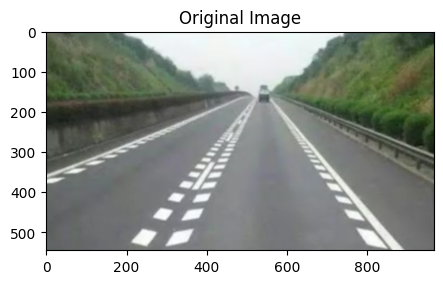

In [2]:
######上传此部分代码######
image = cv2.imread('datasets/road.png')
plt.figure(figsize=(5, 3))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
######上传此部分代码######
plt.show()

2:使用双边滤波对图做image进行平滑去噪，像素邻域査径为9，颜色相似性和空间距商的权重均为50，将输出结果存储在 blured 中

In [3]:
######上传此部分代码######
blurred = cv2.bilateralFilter(image, d=9, sigmaColor=50, sigmaSpace=50)
######上传此部分代码######

3：使用Canny()函数对图像blurred进行边缘检测，其中低阈值为150, 高阈值200, 输出二值化的边缘图像edges

In [4]:
edges = cv2.Canny(blurred, 150, 200)

4：获取图像edges的高度height和宽度width,并使用numpy的相关函数生成一个与edges尺寸相同的全零矩阵mask,用于后续绘制ROI区域。

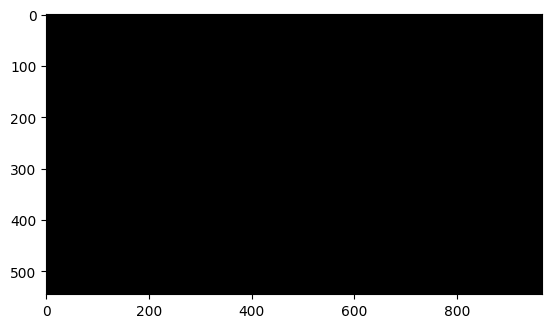

In [5]:
######上传此部分代码######
height, width = edges.shape
mask = np.zeros_like(edges)
######上传此部分代码######
vertices = np.array([[
    (int(width * 0.15), height),
    (int(width * 0.40), int(height * 0.35)),
    (int(width * 0.60), int(height * 0.35)),
    (int(width * 0.95), height)
]], dtype=np.int32)
mask_rgb = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)
plt.imshow(mask_rgb)
plt.show()


5:根据以上定义的vertices,在mask_rgb上绘制梯形，并将梯形内部填充为白色。

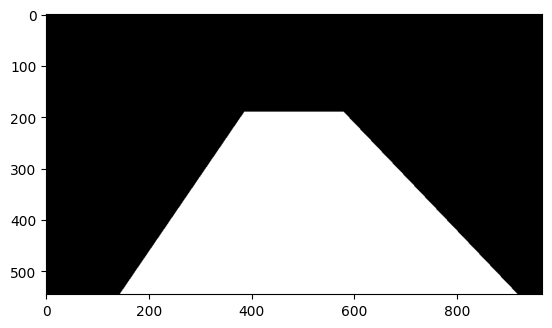

In [6]:
######上传此部分代码######
cv2.fillPoly(mask, vertices, 255)
######上传此部分代码######
mask_rgb = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)
plt.imshow(mask_rgb)
plt.show()

6:使用OpenCV对edges和mask逐像素进行逻辑"与"操作，生成一个只保留ROI内边缘的新图像roi_edges

In [7]:
######上传此部分代码######
roi_edges = cv2.bitwise_and(edges, mask)
######上传此部分代码######

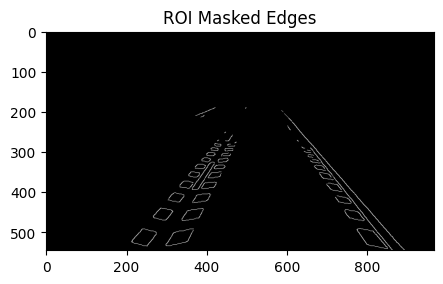

In [8]:
plt.figure(figsize=(5, 3))
plt.imshow(roi_edges, cmap='gray')
plt.title('ROI Masked Edges')
plt.show()

7:使用OpenCV的概率霍夫变换在roi_edges中检测直线段，赋值变量lines。距离分辨率为1, 角度分辨率为PI/180,投票阈值为10,直线小长度为40,同一直线上最大间隔为40。

In [9]:
######上传此部分代码######
lines = cv2.HoughLinesP(
    roi_edges,
    rho=1,
    theta=np.pi / 180,
    threshold=10,
    minLineLength=40,
    maxLineGap=40
)
######上传此部分代码######

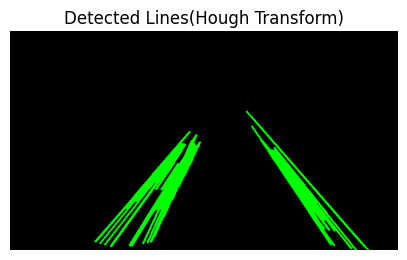

In [10]:
line_image = np.zeros_like(image)
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        angle = np.arctan2(y2 - y1, x2 - x1) * 180.0 / np.pi
        if angle > 20 or angle < -30:
            cv2.line(line_image, (x1, y1), (x2, y2), (0, 255, 0), 4)
plt.figure(figsize=(5, 3))
plt.imshow(cv2.cvtColor(line_image, cv2.COLOR_BGR2RGB))
plt.title('Detected Lines(Hough Transform)')
plt.axis('off')
plt.show()

8:使用OpenCV对image和line_image进行加权融合，权值分别为0.8和1，生成一张新的图像result。

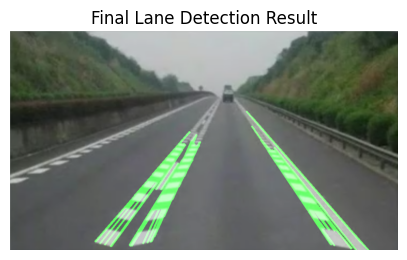

In [11]:
######上传此部分代码######
result = cv2.addWeighted(image, 0.8, line_image, 1, 0)
######上传此部分代码######
plt.figure(figsize=(5, 3))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title('Final Lane Detection Result')
plt.axis('off')
plt.show()